# Imports

In [13]:
from src.data_utils import *
from src.next_token_dataset import *
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


# MOVE TO CONFIG

In [14]:
DATASET_URL = "https://code.s3.yandex.net/deep-learning/tweets.txt"

DATA_PATH = Path("data")
DATA_PATH.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_PATH/"raw_dataset.csv"
DS_PROC_PATH = DATA_PATH/"dataset_processed.csv"
DS_TRAIN_PATH = DATA_PATH/"train.pt"
DS_TEST_PATH = DATA_PATH/"test.pt"
DS_VAL_PATH = DATA_PATH/"val.pt"

MODEL_NAME = "distilgpt2" # наименование предобученной модели

MIN_LENGHT = 8 # минимальная длина твитта в словах

BATCH_SIZE = 256

RANDOM_STATE = 42

# Этап 1. Сбор и поготовка данных

## Загрузка данных

In [3]:
load_raw_data(url=DATASET_URL, save_path=RAW_DATA_PATH)

Файл уже существует: data/raw_dataset.csv


In [4]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print("shape:", df_raw.shape)
df_raw.head()

shape: (698162, 1)


,tweet_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,@Kenichan I dived many times for the ball. Man...
2,"@nationwideclass no, it's not behaving at all...."
3,@Kwesidei not the whole crew \nNeed a hug
4,@LOLTrish hey long time no see! Yes.. Rains a...


## Предобработка данных

In [5]:
df_proc = df_raw.copy()
df_proc["tweet_text"] = df_proc["tweet_text"].apply(lambda x: clean_text(x, min_lenght=MIN_LENGHT))
df_proc = df_proc[df_proc['tweet_text'] != ""].reset_index(drop=True)

print(df_proc.shape)
df_proc.head()

(603194, 1)


,tweet_text
0,awww that s a bummer you shoulda got david car...
1,i dived many times for the ball managed to sav...
2,no it s not behaving at all i m mad why am i h...
3,hey long time no see yes rains a bit only a bi...
4,que me muera spring break in plain city it s s...


In [6]:
df_train, df_temp = train_test_split(df_proc, train_size=0.8, random_state=RANDOM_STATE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

print(f"Train size: {len(df_train)}")
print(f"Val size:   {len(df_val)}")
print(f"Test size:  {len(df_test)}")

Train size: 482555
Val size:   60319
Test size:  60320



Статистика по количеству слов в тексте:
Среднее:  34
Медиана:  25
5-й перцентиль:  9
95-й перцентиль:  87


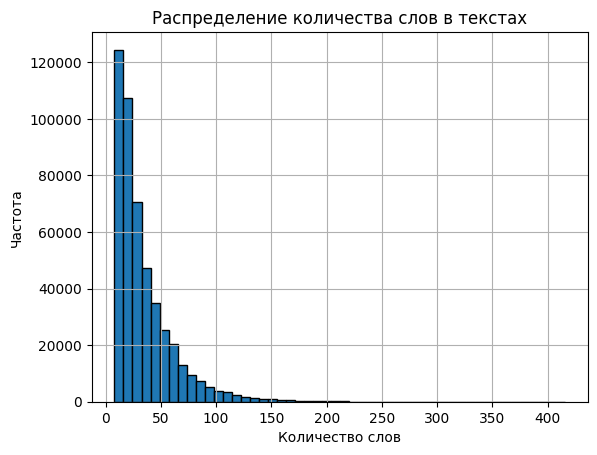

In [7]:
# смотрим статистики твитов для определения параметров
word_counts = torch.tensor([len(seq.split()) for seq in df_train['tweet_text'].values], dtype=torch.float)

print("\nСтатистика по количеству слов в тексте:")
print("Среднее: ", int(word_counts.mean())) 
print("Медиана: ", int(word_counts.median())) 
print("5-й перцентиль: ", int(word_counts.quantile(0.05)))
print("95-й перцентиль: ", int(word_counts.quantile(0.95))) 

# Гистограмма распределения длины
plt.hist(word_counts, bins=50, edgecolor='black')
plt.title("Распределение количества слов в текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

In [9]:
if DS_TRAIN_PATH.exists() and DS_TEST_PATH.exists() and DS_VAL_PATH.exists():
    print("загрузка данных...")
    train_encodings = torch.load(DS_TRAIN_PATH, weights_only=False)
    test_encodings = torch.load(DS_TEST_PATH, weights_only=False)
    val_encodings = torch.load(DS_VAL_PATH, weights_only=False)
    print('данные загружены')
else:
    print("обработка данных...")
    train_encodings = tokenize_function(df_train["tweet_text"], tokenizer=tokenizer)
    test_encodings = tokenize_function(df_test["tweet_text"], tokenizer=tokenizer)
    val_encodings = tokenize_function(df_val["tweet_text"], tokenizer=tokenizer)

    torch.save(train_encodings, DS_TRAIN_PATH)
    torch.save(test_encodings, DS_TEST_PATH)
    torch.save(val_encodings, DS_VAL_PATH)

    print("данные сохранены")

print("train_encodings:", train_encodings['input_ids'].shape)
print("train_encodings:", test_encodings['input_ids'].shape)
print("train_encodings:", val_encodings['input_ids'].shape)

обработка данных...
данные сохранены
train_encodings: torch.Size([482555, 128])
train_encodings: torch.Size([60320, 128])
train_encodings: torch.Size([60319, 128])


In [10]:
train_encodings["input_ids"][0]

tensor([  361,   673,   288,   286,  2227,   340,   588,   326,   788,   407,
          257,  1917,   475, 21098,   645,   673, 42547,   508,  2840,   423,
        22999,   262,  1353,   286,   616, 22645,   706,   477,   326,   640,
          319,   262, 10481,  8066,  5001,   257, 14996,   649,  2042, 10999,
         1909,   288, 11752,   703,  1312,  4601,   340,   561,  2652, 27737,
          329,  2392,   356,  1569,   550, 21140,  6193,   329,   262,  1613,
          604,  1528, 20766,   340,  5645,  9975,  8066,   423,   284,  3100,
          883,  7374,  8242,   503,  1865,   757,  1489, 13321,    78,  5875,
          345,   477,  2534,  1909,  4203,   257,  1643,  5210,  2000, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])

## Формирование датасета

In [15]:
train_dataset = TweetDataset(train_encodings)
test_dataset = TweetDataset(test_encodings)
val_dataset = TweetDataset(val_encodings)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f'train_dataset: {len(train_dataset)}, '
      f'test_dataset: {len(test_dataset)}, ' 
      f'val_dataset: {len(val_dataset)}')

print(f'train_dataloader: {len(train_dataloader)}, '
      f'test_dataloader: {len(test_dataloader)}, ' 
      f'val_dataloader: {len(val_dataloader)}')

train_dataset: 482555, test_dataset: 60320, val_dataset: 60319
train_dataloader: 1885, test_dataloader: 236, val_dataloader: 236


# Этап 2. Реализация рекуррентой сети